# Decoding the IPL: Can Data Predict the Next Champion?
**Analytics Induction Programme | IPL Dataset 2008–2022**

## Section 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


## Section 1 — Load and Inspect Data

In [3]:
matches = pd.read_csv('Dataset1.csv')
balls    = pd.read_csv('IPL_Ball_by_Ball_2008_2022.csv')

print('matches shape:', matches.shape)
print('balls shape   :', balls.shape)

matches shape: (950, 20)
balls shape   : (225954, 17)


In [4]:
# First few rows
matches.head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


In [5]:
# Data types and null counts
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [6]:
# Descriptive statistics
matches.describe(include='all')

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
count,9.500000e+02,899,950,950,950,950,950,950,950,950,946,946,950,932.000000,19,946,950,950,950,950
unique,NaN,33,706,15,80,18,18,49,18,2,2,18,4,NaN,1,262,932,937,58,60
top,NaN,Mumbai,2008-04-20,2013,Final,Royal Challengers Bangalore,Mumbai Indians,Eden Gardens,Mumbai Indians,field,N,Mumbai Indians,Wickets,NaN,D/L,AB de Villiers,"['KL Rahul', 'MA Agarwal', 'CH Gayle', 'DJ Hoo...","['BB McCullum', 'CH Gayle', 'BJ Hodge', 'SC Ga...",AK Chaudhary,S Ravi
freq,NaN,159,2,76,15,126,119,77,123,599,932,131,509,NaN,19,25,2,2,95,83
mean,8.304852e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.056867,NaN,NaN,NaN,NaN,NaN,NaN
std,3.375678e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.633109,NaN,NaN,NaN,NaN,NaN,NaN
min,3.359820e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.012612e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,8.297380e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.175372e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,NaN


## Section 2 — Data Cleaning

In [7]:
# Remove no-result matches (4 rows)
matches = matches[matches['WonBy'] != 'NoResults'].copy()
matches.reset_index(drop=True, inplace=True)

# Fix season label (e.g. '2007/08' -> '2008')
matches['Season'] = matches['Season'].astype(str)
matches['Season'] = matches['Season'].replace({
    '2007/08': '2008', '2009/10': '2010', '2020/21': '2020'
})

print('Rows after cleaning:', len(matches))
print('Null counts in key columns:')
print(matches[['Team1','Team2','Venue','TossWinner','TossDecision','WinningTeam']].isnull().sum())

Rows after cleaning: 946
Null counts in key columns:
Team1           0
Team2           0
Venue           0
TossWinner      0
TossDecision    0
WinningTeam     0
dtype: int64


In [8]:
# Create target variable: bat_first_won
# If TossDecision == 'bat', TossWinner batted first
# Else the other team batted first

def is_bat_first_won(row):
    if row['TossDecision'] == 'bat':
        if row['TossWinner']==row['WinningTeam']:
            return 1
        else:
            return 0;
    else:
        if row['TossWinner']==row['WinningTeam']:
            return 0
        else:
            return 1;

matches['bat_first_won'] = matches.apply(is_bat_first_won, axis=1)
print(f"Bat first Win Rate: {(matches['bat_first_won'].mean()*100).round(3)}%")

Bat first Win Rate: 44.926%


In [9]:
# Compute innings totals from ball-by-ball data
innings = balls.groupby(['ID', 'innings'])['total_run'].sum().reset_index()
innings.columns = ['ID', 'innings', 'score']
print('Innings Dataset Shape :',innings.shape)
display(innings)

print('Unique Values in Innings Column : ')
print(innings['innings'].unique())

print('But We only need Inning Number 1 or 2 \nSo We Need To Filter Data')
innings = innings[innings['innings'].isin([1, 2])]

print('After Filteration :', '\nInnings Dataset Shape :', innings.shape)

print('\nInnings score statistics:')
print(innings['score'].describe().round(2))


Innings Dataset Shape : (1928, 3)


,ID,innings,score
0,335982,1,222
1,335982,2,82
2,335983,1,240
3,335983,2,207
4,335984,1,129
...,...,...,...
1923,1312198,2,193
1924,1312199,1,157
1925,1312199,2,161
1926,1312200,1,130


Unique Values in Innings Column : 
[1 2 3 4 5 6]
But We only need Inning Number 1 or 2 
So We Need To Filter Data
After Filteration : 
Innings Dataset Shape : (1898, 3)

Innings score statistics:
count    1898.00
mean      155.85
std        31.21
min         2.00
25%       137.00
50%       158.00
75%       176.75
max       263.00
Name: score, dtype: float64


## Section 3 — Statistical Visualisation

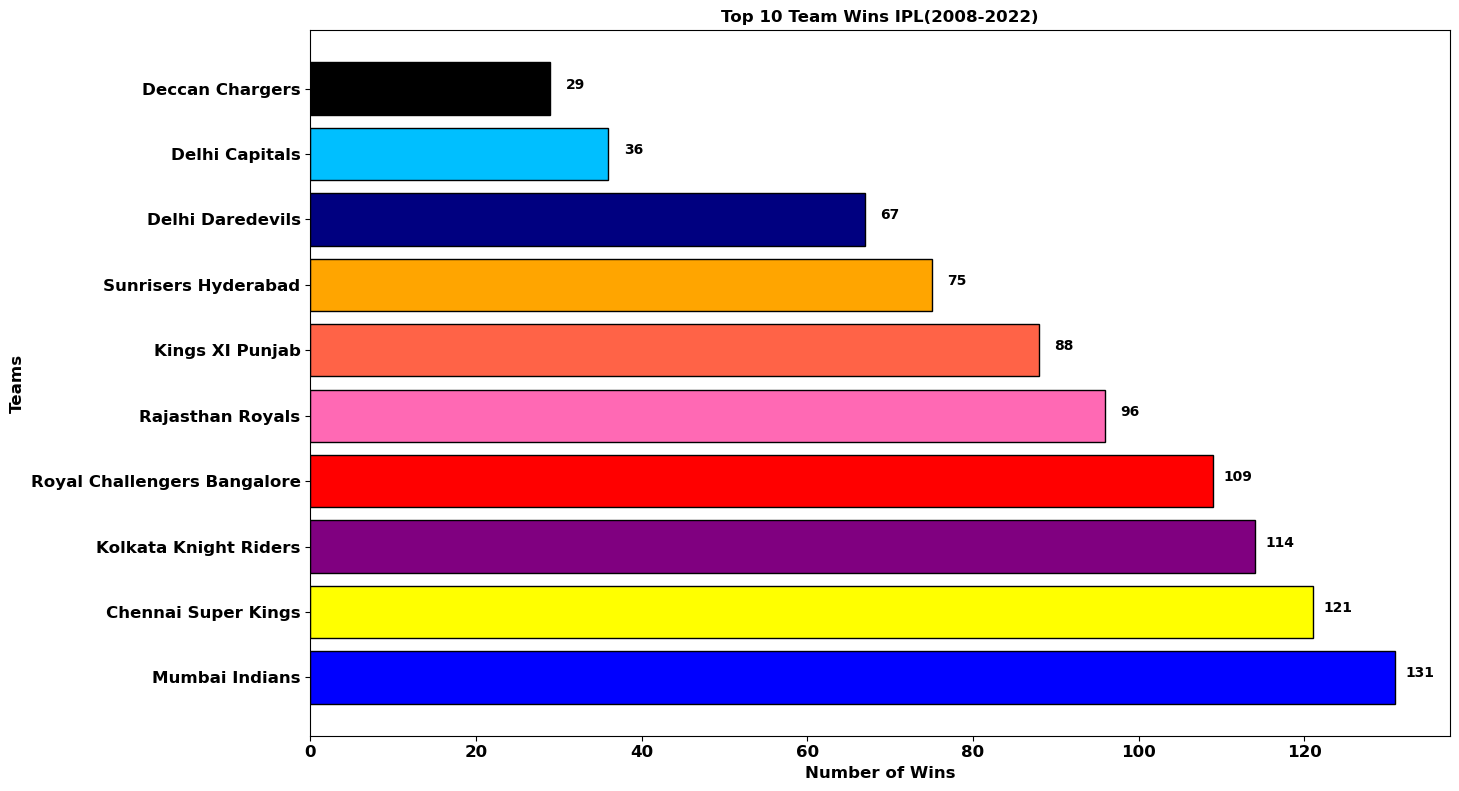

In [10]:
# Plot 1: Bar Chart — Total wins by team
wins = matches['WinningTeam'].value_counts().head(10)
teams = wins.index
plt.figure(figsize=(14,8))
plt.barh(wins.index, wins, edgecolor='black',color = [
    "blue", "yellow", "purple", "red", "hotpink", "tomato",
    "orange", "navy", "deepskyblue", "black"
])
plt.title('Top 10 Team Wins IPL(2008-2022)', fontsize=12, fontweight='bold')
plt.ylabel('Teams',fontsize=12, fontweight='bold')
plt.xlabel('Number of Wins', fontsize=12, fontweight='bold')
for i in teams:
    plt.text(wins[i]+3, i, wins[i], ha="center", fontsize=10, fontweight='bold')  
    
plt.tight_layout()
plt.xticks(color='black', fontsize=12, fontweight='bold')
plt.yticks(color='black', fontsize=12, fontweight='bold')
plt.savefig('Plots/team_wins.png',dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()

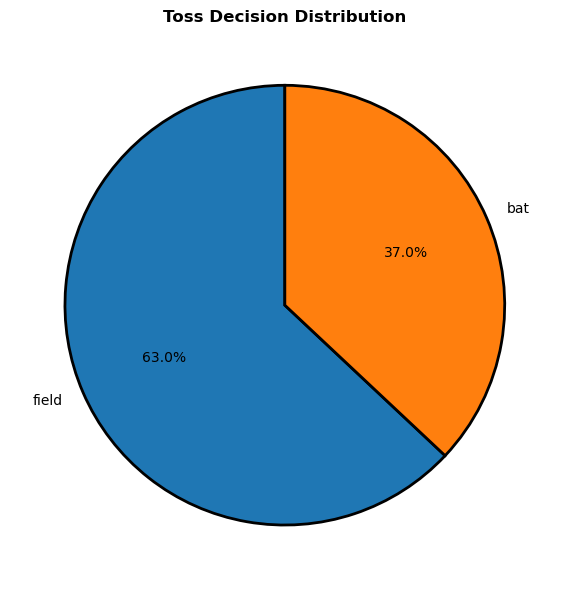

In [11]:
# Plot 2: Pie Chart — Toss decision distribution
toss_counts = matches['TossDecision'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(toss_counts, labels=toss_counts.index, autopct='%1.1f%%', startangle=90,wedgeprops={"edgecolor":"black", "linewidth": 2, "linestyle":"-"})
plt.title('Toss Decision Distribution',fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('Plots/toss_pie.png',dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()

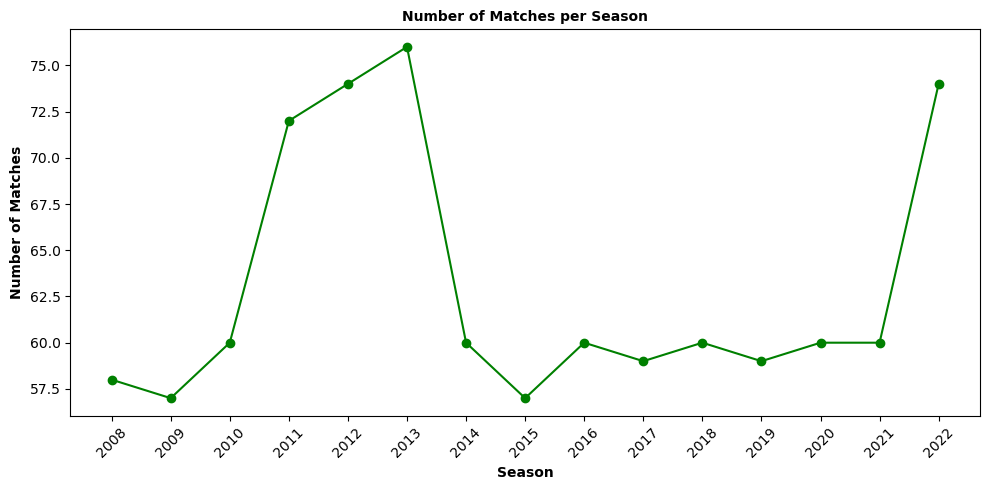

In [12]:
# Plot 3: Line Chart — Matches per season
season_counts = matches.groupby('Season')['ID'].count()
plt.figure(figsize=(10, 5))
plt.plot(season_counts.index, season_counts.values, marker='o', color='green')
plt.title('Number of Matches per Season', fontsize=10, fontweight='bold')
plt.xlabel('Season', fontsize=10, fontweight='bold')
plt.ylabel('Number of Matches', fontsize=10, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Plots/matches_per_season.png', dpi=300)
plt.show()

In [13]:
# Making a heatmap dataframe for Heatmap
top_teams  = matches['WinningTeam'].value_counts().head(6).index
top_venues = matches['Venue'].value_counts().head(8).index
heatmap_df = matches[matches['WinningTeam'].isin(top_teams) & matches['Venue'].isin(top_venues)].groupby(['Venue', 'WinningTeam']).size().unstack(fill_value=0)
heatmap_df

WinningTeam,Chennai Super Kings,Kings XI Punjab,Kolkata Knight Riders,Mumbai Indians,Rajasthan Royals,Royal Challengers Bangalore
Venue,,,,,,
Dubai International Cricket Stadium,9,5,3,3,2,8
Eden Gardens,5,3,45,10,2,4
Feroz Shah Kotla,5,4,5,3,4,5
M Chinnaswamy Stadium,4,5,6,8,3,29
"MA Chidambaram Stadium, Chepauk",33,2,2,3,1,2
"Rajiv Gandhi International Stadium, Uppal",2,4,4,5,2,2
Sawai Mansingh Stadium,3,1,3,2,32,3
Wankhede Stadium,7,5,1,42,4,3


In [14]:
[v[:30] for v in heatmap_df.index]

['Dubai International Cricket St',
 'Eden Gardens',
 'Feroz Shah Kotla',
 'M Chinnaswamy Stadium',
 'MA Chidambaram Stadium, Chepau',
 'Rajiv Gandhi International Sta',
 'Sawai Mansingh Stadium',
 'Wankhede Stadium']

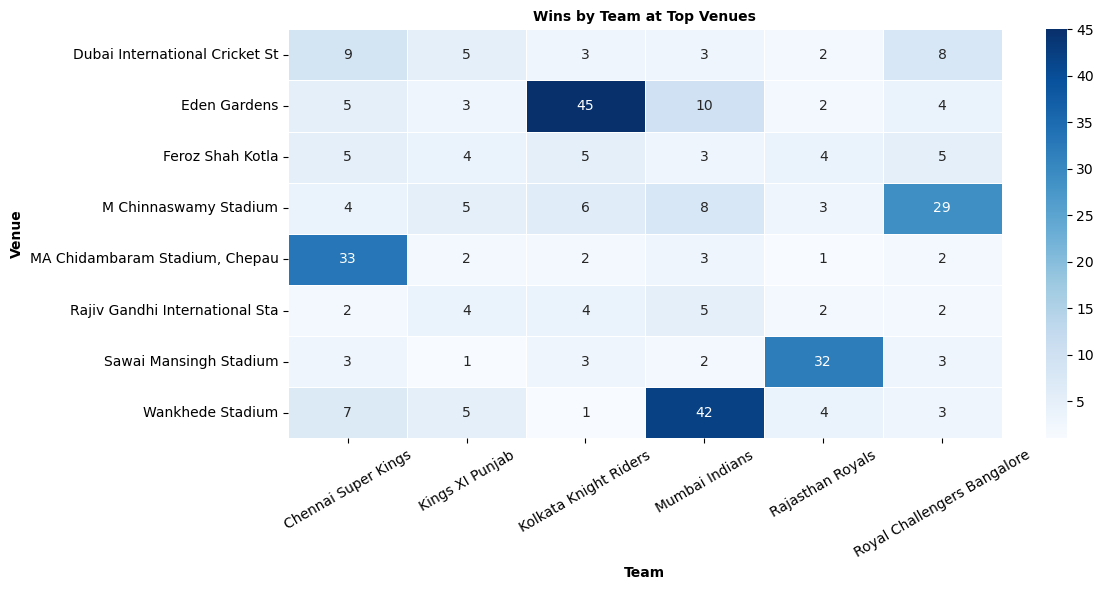

In [15]:
# Plot 4: Heatmap — Wins by team at top venues
heatmap_df.index = [v[:30] for v in heatmap_df.index]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Wins by Team at Top Venues', fontsize=10, fontweight='bold')
plt.xlabel('Team',fontsize=10, fontweight='bold')
plt.ylabel('Venue', fontsize=10, fontweight='bold')
plt.xticks(rotation=30, ha='center')
plt.tight_layout()
plt.savefig('Plots/venue_heatmap.png', dpi=300)
plt.show()

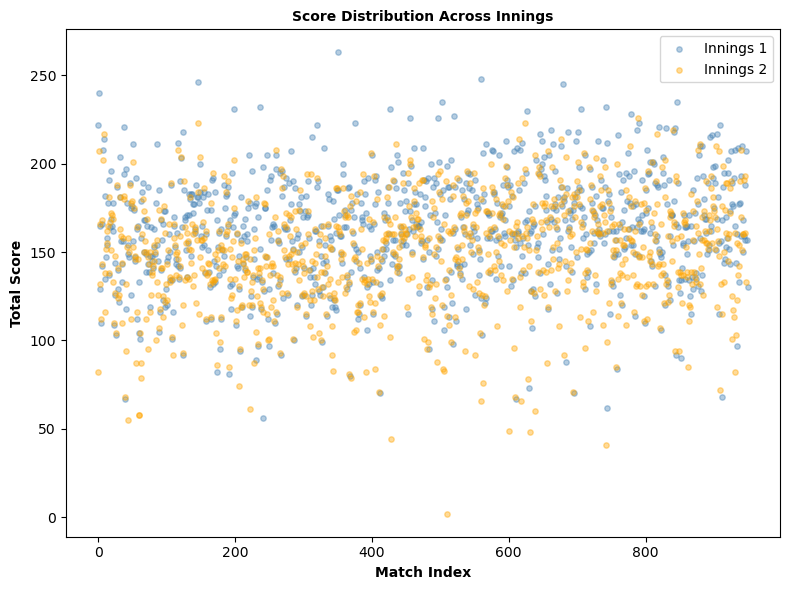

In [16]:
# Plot 5: Scatter Plot — Score distribution across innings
inning1 = innings[innings['innings'] == 1]['score']
inning2 = innings[innings['innings'] == 2]['score']

plt.figure(figsize=(8, 6))
plt.scatter(range(len(inning1)), inning1.values, alpha=0.4, s=15,
            label='Innings 1', color='steelblue')
plt.scatter(range(len(inning2)), inning2.values, alpha=0.4, s=15,
            label='Innings 2', color='orange')
plt.title('Score Distribution Across Innings', fontsize=10, fontweight='bold')
plt.xlabel('Match Index', fontsize=10, fontweight='bold')
plt.ylabel('Total Score', fontsize=10, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('Plots/score_distribution.png', dpi=300)
plt.show()

## Section 4 — Outlier Detection

In [17]:
scores = innings['score'].values

# Method 1: IQR
Q1 = np.percentile(scores, 25)
Q3 = np.percentile(scores, 75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = innings[(innings['score'] < lower) | (innings['score'] > upper)]

print('--- IQR Method ---')
print(f'Q1 = {Q1},  Q3 = {Q3},  IQR = {IQR}')
print(f'Lower fence = {lower:.1f},  Upper fence = {upper:.1f}')
print(f'Number of outliers: {len(iqr_outliers)}')

# Method 2: Z-Score
z = np.abs(zscore(scores))
z_outliers = innings[z > 3]

print('\n--- Z-Score Method ---')
print(f'Number of outliers (|z| > 3): {len(z_outliers)}')

print('\n--- Comparison ---')
print(f'IQR outliers  : {len(iqr_outliers)}')
print(f'Z-score outliers: {len(z_outliers)}')
print('The IQR method is more sensitive and catches more moderate outliers.')
print('The Z-score method is stricter and only catches the most extreme values.')

--- IQR Method ---
Q1 = 137.0,  Q3 = 176.75,  IQR = 39.75
Lower fence = 77.4,  Upper fence = 236.4
Number of outliers: 32

--- Z-Score Method ---
Number of outliers (|z| > 3): 13

--- Comparison ---
IQR outliers  : 32
Z-score outliers: 13
The IQR method is more sensitive and catches more moderate outliers.
The Z-score method is stricter and only catches the most extreme values.


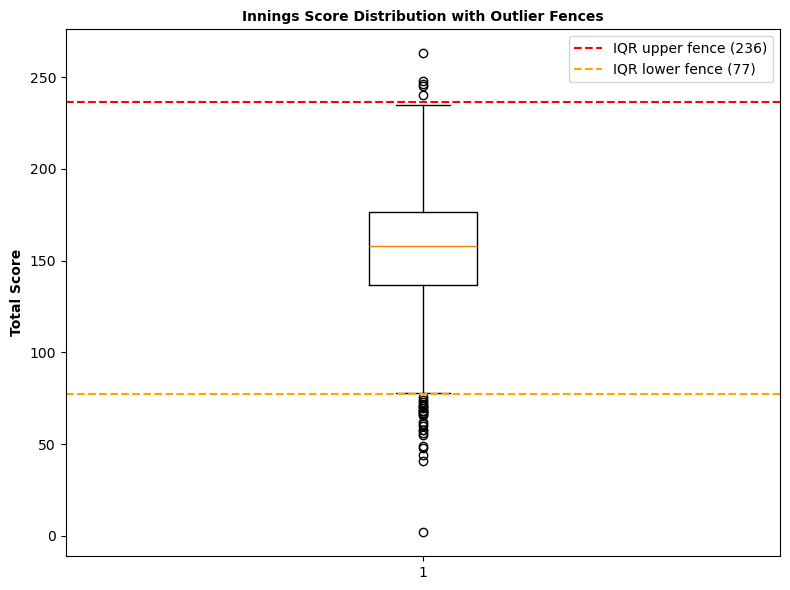

In [18]:
# Plot 6: Box Plot — Outlier detection
plt.figure(figsize=(8, 6))
plt.boxplot(scores, vert=True)
plt.axhline(upper, color='red', linestyle='--', label=f'IQR upper fence ({upper:.0f})')
plt.axhline(lower, color='orange', linestyle='--', label=f'IQR lower fence ({lower:.0f})')
plt.title('Innings Score Distribution with Outlier Fences', fontsize=10, fontweight='bold')
plt.ylabel('Total Score', fontsize=10, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('Plots/outlier_boxplot.png', dpi=300)
plt.show()

## Section 5 — Feature Engineering and Model Construction

In [19]:
# Cleaning Venue Column
matches['Venue'].replace({
    'Eden Gardens, Kolkata':'Eden Gardens',
    'Wankhede Stadium, Mumbai':'Wankhede Stadium',
    'M.Chinnaswamy Stadium':'M Chinnaswamy Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai':'MA Chidambaram Stadium, Chepauk',
    'MA Chidambaram Stadium':'MA Chidambaram Stadium, Chepauk',
    'Rajiv Gandhi International Stadium, Uppal':'Rajiv Gandhi International Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali':'Punjab Cricket Association Stadium',
    'Punjab Cricket Association Stadium, Mohali':'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium':'Punjab Cricket Association Stadium',
    'Maharashtra Cricket Association Stadium, Pune':'Maharashtra Cricket Association Stadium',
    'Dr DY Patil Sports Academy, Mumbai':'Dr DY Patil Sports Academy',
    'Brabourne Stadium, Mumbai':'Brabourne Stadium',
    'Arun Jaitley Stadium, Delhi':'Arun Jaitley Stadium',
}, inplace=True)

In [20]:
len(matches['Venue'].value_counts().index)

37

In [21]:
# Making a New binary feature team1_won_toss
def is_team1_won_toss(row):
    if row['TossWinner']==row['Team1']:
        return 1
    else:
        return 0
matches['team1_won_toss'] = matches.apply(is_team1_won_toss, axis=1)

In [22]:
# Prepare features and target
model_df = matches[['Venue','Team1', 'Team2', 'team1_won_toss',
                     'TossDecision', 'bat_first_won']].dropna().copy()

# Encoding TossDecision Column
model_df['TossDecision'] = model_df['TossDecision'].replace({'bat':1, 'field':0})

# One-hot encode Venue, Team1, Team2
model_df = pd.get_dummies(model_df, columns=['Venue','Team1', 'Team2'], drop_first=True, dtype=int)

#After Feature Engineering Model Dataframe
display(model_df)
print(model_df.shape)
model_df.info()

,team1_won_toss,TossDecision,bat_first_won,Venue_Barabati Stadium,Venue_Brabourne Stadium,Venue_Buffalo Park,Venue_De Beers Diamond Oval,Venue_Dr DY Patil Sports Academy,Venue_Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium,Venue_Dubai International Cricket Stadium,...,Team2_Kolkata Knight Riders,Team2_Lucknow Super Giants,Team2_Mumbai Indians,Team2_Pune Warriors,Team2_Punjab Kings,Team2_Rajasthan Royals,Team2_Rising Pune Supergiant,Team2_Rising Pune Supergiants,Team2_Royal Challengers Bangalore,Team2_Sunrisers Hyderabad
0,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
942,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
943,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
944,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


(946, 73)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946 entries, 0 to 945
Data columns (total 73 columns):
 #   Column                                                     Non-Null Count  Dtype
---  ------                                                     --------------  -----
 0   team1_won_toss                                             946 non-null    int64
 1   TossDecision                                               946 non-null    int64
 2   bat_first_won                                              946 non-null    int64
 3   Venue_Barabati Stadium                                     946 non-null    int64
 4   Venue_Brabourne Stadium                                    946 non-null    int64
 5   Venue_Buffalo Park                                         946 non-null    int64
 6   Venue_De Beers Diamond Oval                                946 non-null    int64
 7   Venue_Dr DY Patil Sports Academy                           946 non-null    int64
 8   Venue_Dr. Y.S. Rajas

In [23]:
X = model_df.drop('bat_first_won', axis=1)
y = model_df['bat_first_won']
# Stratified train-test split (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test size :', len(X_test))

# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print('Model trained successfully')

Train size: 756
Test size : 190
Model trained successfully


## Section 6 — Model Evaluation

In [24]:
# Metrics for both train and test sets
results = {}
for name, Xd, yd in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    pred = model.predict(Xd)
    prob = model.predict_proba(Xd)[:, 1]
    results[name] = {
        'Accuracy' : round(accuracy_score(yd, pred), 4),
        'Precision': round(precision_score(yd, pred), 4),
        'Recall'   : round(recall_score(yd, pred), 4),
        'F1-Score' : round(f1_score(yd, pred), 4),
        'AUC'      : round(roc_auc_score(yd, prob), 4),
    }

# D3 — Metric Summary Table
summary = pd.DataFrame(results).T
print('--- D3: Metric Summary Table ---')
display(summary)

--- D3: Metric Summary Table ---


,Accuracy,Precision,Recall,F1-Score,AUC
Train,0.6376,0.6387,0.4471,0.5260,0.6811
Test,0.5368,0.4789,0.4000,0.4359,0.5393


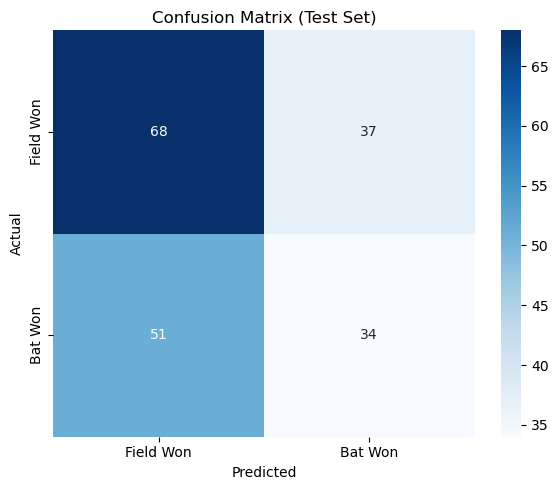

In [25]:
# Plot 7: Confusion Matrix
test_pred = model.predict(X_test)
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Field Won', 'Bat Won'],
            yticklabels=['Field Won', 'Bat Won'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('Plots/confusion_matrix.png', dpi=300)
plt.show()

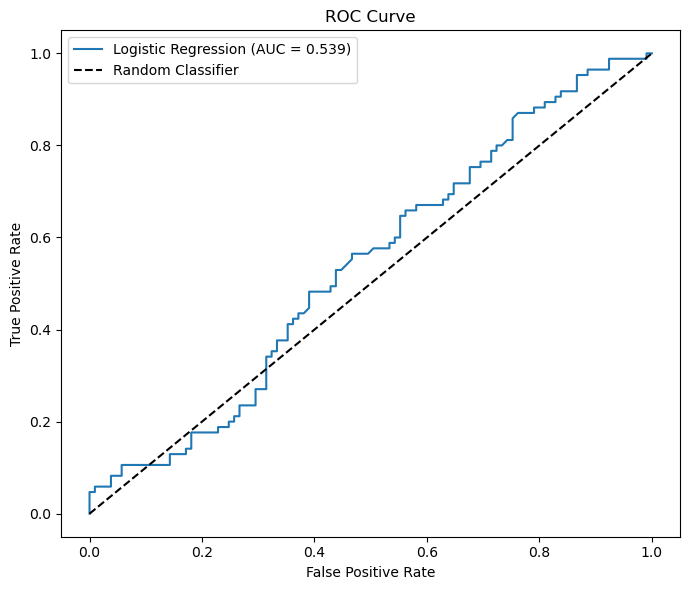

In [26]:
# Plot 8: ROC Curve
test_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, test_prob)
auc = roc_auc_score(y_test, test_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('Plots/roc_curve.png', dpi=300)
plt.show()

## Section 7 — Chi-Square Hypothesis Test

In [27]:
# Chi-Square test: Is toss decision associated with match outcome?
# H0: Toss decision and bat_first_won are independent
# H1: They are associated

ct = pd.crosstab(matches['TossDecision'], matches['bat_first_won'])
print('Contingency Table:')
print(ct)

chi2, p, dof, expected = chi2_contingency(ct)

# D4 — Statistical Test Result
print(f'\nChi-Square Statistic : {chi2:.4f}')
print(f'Degrees of Freedom   : {dof}')
print(f'p-value              : {p:.6f}')

if p < 0.05:
    print('Result: Reject H0 means toss decision IS significantly associated with match outcome.')
else:
    print('Result: Fail to reject H0 means toss decision is NOT significantly associated with match outcome (p > 0.05).')

Contingency Table:
bat_first_won    0    1
TossDecision           
bat            191  159
field          330  266

Chi-Square Statistic : 0.0291
Degrees of Freedom   : 1
p-value              : 0.864659
Result: Fail to reject H0 means toss decision is NOT significantly associated with match outcome (p > 0.05).


## Section 8 — Written Reflection (D5)

**Q1. What patterns in the data were most surprising?**

The most surprising finding was that teams batting first win only about 44.9% of matches, meaning the chasing team has a slight advantage overall. This goes against the common assumption that posting a big total always gives a team the upper hand in T20 cricket.

Another surprising observation was the extreme range of innings scores — from as low as 2 runs to as high as 263 runs. These extreme values show how unpredictable T20 cricket can be, with some matches being completely one-sided.

**Q2. How did the IQR and Z-score methods differ in detecting outliers?**

The IQR method flagged 32 innings as outliers by setting fences at [77.4, 236.4], based on Q1=137.0 and Q3=176.75. It is more sensitive because it uses the spread of the middle 50% of data, so it also catches moderate extremes like scores in the 60–76 range.

The Z-score method flagged only 13 innings (those with |z| > 3), which is a stricter criterion requiring a value to be more than 3 standard deviations from the mean. All 13 Z-score outliers were already caught by IQR, meaning the IQR method is a superset of the Z-score method in this dataset.

**Q3. How well did the Logistic Regression model perform?**

The model achieved a test accuracy of 53.68% and a test AUC of 0.539, which is only slightly better than random guessing (50% accuracy, AUC = 0.5). The training accuracy was 63.76% and training AUC was 0.681, showing that the model overfits somewhat — it learns the training data better than it generalises to new matches.

This limited performance makes sense: the features used (venue, team names, toss decision) are weak predictors because IPL outcomes depend heavily on in-match factors like player form, pitch conditions, and dew — none of which are captured here.

**Q4. What did the Chi-Square test reveal about the toss decision?**

The Chi-Square test returned a statistic of 0.0291 with 1 degree of freedom and a p-value of 0.8647, which is far above the significance level of 0.05. This means we fail to reject the null hypothesis — toss decision (bat or field) is not significantly associated with match outcome.

In simple terms, captains who choose to bat after winning the toss do not have a measurably different chance of their team winning compared to those who choose to field. The data from 15 seasons of IPL confirms this statistically.

**Q5. What would you improve if you did this project again?**

The most important improvement would be adding stronger features. For example, each team's win rate in their last 5 matches, head-to-head records between the two specific teams, and each team's average score at that particular venue. These features would capture current form and historical matchup patterns that team identity alone cannot.

I would also try more advanced models like Random Forest, which can find non-linear patterns in the data, and use cross-validation instead of a single train-test split to get a more reliable estimate of model performance.

## Final Deliverables Checklist

| # | Deliverable | Status |
|---|-------------|--------|
| D1 | Jupyter Notebook (this file) | ✅ |
| D2 | 8 PNG plots saved | ✅ |
| D3 | Metric summary table (Section 6) | ✅ |
| D4 | Chi-Square result (Section 7) | ✅ |
| D5 | 5 reflection answers (Section 8) | ✅ |
| D6 | analysis_report.pdf | ✅ |